### [GitHub](https://github.com/msultanmahmud/Stress_WESAD/blob/master/Multiclass_Pipeline_Individual_sub_INTEC.ipynb)

In [2]:
# ! pip list

In [3]:
# ! pip install lightgbm

In [4]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics,preprocessing
#from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt
from collections import Counter
from scipy.stats import norm
import seaborn as sns; sns.set(font_scale=1.2)
%matplotlib inline
import time
import xgboost as xgb
import lightgbm as lgb

#### Redaing file

In [11]:
df=pd.read_csv('../dreamt_preprocessed.csv')
df.subject.nunique()

100

In [13]:
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]

# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df.head(5) 

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625


### Drop subject those who have some data Msisning 

In [16]:
df = df[~df['subject'].isin(['S062', 'S097'])]
pre_procss_all=df.copy()
pre_procss_all

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


In [18]:
## >>>>>> PPG DATA Separation done <<<<<<<<<<<<

In [20]:
wanted_keywords = ['BVP', 'EDA', 'TEMP', 'ACC_X', 'ACC_Y', 'ACC_Z', 'HR', 'IBI']
pattern = '|'.join(wanted_keywords)
 
# Select columns that do NOT match the regex pattern
df_psg = pre_procss_all.loc[:, ~pre_procss_all.columns.str.contains(pattern, case=False, regex=True)]
df_psg
# Drop columns with any null (NaN) values
df_psg_cleaned = df_psg.dropna(axis=1, how='any')
# Optionally: print removed columns
psg_removed_cols = df_psg.columns[df_psg.isnull().any()].tolist()
print("Removed columns with nulls:", psg_removed_cols)
df_psg_cleaned
 
df_psg_cleaned = df_psg_cleaned[df_psg_cleaned['label'].isin([0,1,2])]
df_psg_cleaned.head(3)

Removed columns with nulls: []


,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,RAT_p95,SAO2_min,SAO2_max,SAO2_mean,SAO2_std,SAO2_p5,SAO2_p25,SAO2_p50,SAO2_p75,SAO2_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,0.000007,0.969907,0.969941,0.969924,0.000006,0.969915,0.969919,0.969924,0.969930,0.969934
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,0.000005,0.958276,0.971334,0.966985,0.004638,0.959652,0.959699,0.969916,0.969931,0.969956
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,0.000006,0.969916,0.969933,0.969924,0.000004,0.969918,0.969920,0.969924,0.969929,0.969931


In [22]:
### How many subjec
sample=df_psg_cleaned.subject.unique()[:15]
# # Sample the data (if needed)
df_sample = df_psg_cleaned[df_psg_cleaned.subject.isin(sample)]
df_sample.head()
# df=df_psg_cleaned.copy()

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,RAT_p95,SAO2_min,SAO2_max,SAO2_mean,SAO2_std,SAO2_p5,SAO2_p25,SAO2_p50,SAO2_p75,SAO2_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,0.000007,0.969907,0.969941,0.969924,0.000006,0.969915,0.969919,0.969924,0.969930,0.969934
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,0.000005,0.958276,0.971334,0.966985,0.004638,0.959652,0.959699,0.969916,0.969931,0.969956
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,0.000006,0.969916,0.969933,0.969924,0.000004,0.969918,0.969920,0.969924,0.969929,0.969931
308,S002,310,0.0,-0.000018,0.000017,1.591821e-08,0.000005,-0.000008,-0.000003,4.882887e-08,...,0.000005,0.969920,0.969929,0.969924,0.000003,0.969920,0.969922,0.969924,0.969927,0.969929
309,S002,311,0.0,-0.000052,0.000067,1.513695e-07,0.000010,-0.000017,-0.000003,4.394598e-07,...,0.000010,0.969921,0.969928,0.969924,0.000001,0.969922,0.969924,0.969924,0.969925,0.969927


In [24]:
# df1=df_fusion_cleaned.copy()
# df1.head(3)

## Reading the stability score pickle that was save during the satability selection analysis

In [27]:
# with open("results_ss_v1.pkl", "rb") as f:
with open("stability_score_alpha_psg_v1.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

In [29]:
# # Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]

# # Filter the dictionary
# results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
# results_filtered
# import pickle
# with open("stability_score_alpha_whole_v1.pkl", "wb") as f:
#     pickle.dump(results_filtered, f)


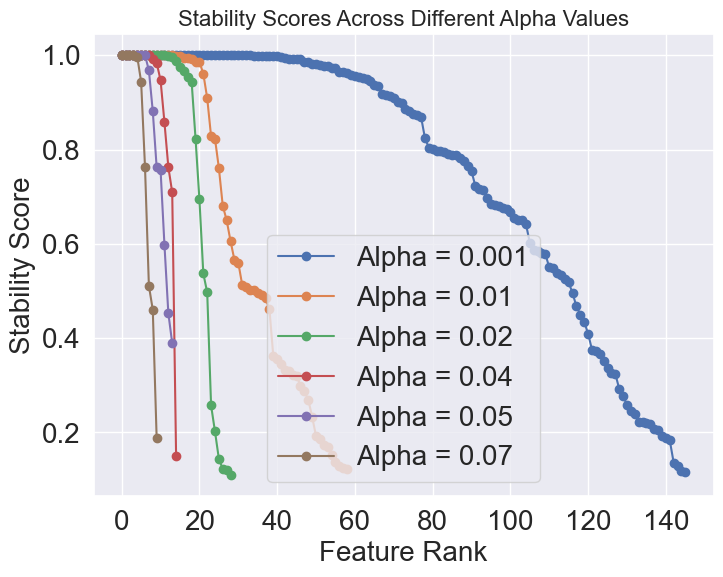

In [31]:
# Plot stability scores for each alpha
fs=20
plt.figure(figsize=(8, 6))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=fs)
plt.ylabel('Stability Score',fontsize=fs)
plt.xticks(fontsize=fs)  # Make x-axis tick labels larger
plt.yticks(fontsize=fs)  # Make y-axis tick labels larger
plt.legend(fontsize=fs,loc='lower center')
plt.grid(True)
plt.show()

In [33]:
feature_importance_df_07=results[0.07][results[0.07].Stability_Score>=0.7]['Feature'].values
sel_col=np.append(feature_importance_df_07,'label')
### Selected features only
df1=df_sample[sel_col]
df1.head(3)

,ECG_min,ABDOMEN_min,CHIN_p25,RAT_max,FP1-O2_std,LAT_min,RAT_min,label
305,-0.000207,-0.000471,-0.000004,0.000047,0.000018,-0.000070,-0.000046,0.0
306,-0.000223,-0.000599,-0.000004,0.000012,0.000010,-0.000010,-0.000028,0.0
307,-0.000250,-0.000575,-0.000004,0.000019,0.000014,-0.000011,-0.000026,0.0


In [35]:
#   df_sample.subject.nunique()

### Classification based on the selected Features

In [39]:
# !jupyter kernelspec list

In [41]:
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import pandas as pd
import numpy as np

def preprocess_scaling(df):
    '''Scales features and splits into train/test.'''
    X = df.drop(columns=['label'])
    y = df['label']
    X_scaled = preprocessing.scale(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # AUC calculation — multi-class
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None  # SVM without probability=True will not support this

        return (model_name, acc, f1, precision, recall, auc)
    except Exception as e:
        print(f"Error with model {model_name}: {e}")
        return (model_name, None, None, None, None, None)

def multiple_model(df, auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)
    model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']

    # SVM needs probability=True for predict_proba
    models = [
        KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2),
        DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50),
        xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), random_state=42,
                          max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                          min_child_weight=1, eval_metric='mlogloss', n_jobs=-1),
        lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                           min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1),
        RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1),
        svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=True)  # Required for AUC
    ]

    results_list = Parallel(n_jobs=-1)(delayed(train_and_evaluate)(
        model, X_train, y_train, X_test, y_test, name, auc_mode
    ) for model, name in zip(models, model_name_list))

    results_df = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC'])
    results_df.set_index('Model', inplace=True)
    results_df=results_df[['Accuracy','AUC','Precision', 'Recall','F1']]
    return results_df

### Ensemble Learning

In [44]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

def ensemble_model(df, voting_type='hard', auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)

    # Define base models
    knn = KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2)
    dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50)
    xgb_model = xgb.XGBClassifier(objective='multi:softprob', random_state=42, min_child_weight=1,
                                  max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                                  eval_metric='mlogloss', n_jobs=-1, use_label_encoder=False)
    lgb_model = lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                                   min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1)
    rf = RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1)
    svc = svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=(voting_type == 'soft'))

    # Create ensemble using voting
    ensemble = VotingClassifier(
        estimators=[
            ('KNN', knn),
            ('DT', dt),
            ('XGB', xgb_model),
            ('LGBM', lgb_model),
            ('RF', rf),
            ('SVM', svc)
        ],
        voting=voting_type,
        n_jobs=-1
    )

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Compute AUC only if voting_type is 'soft'
    try:
        if voting_type == 'soft':
            y_probs = ensemble.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None
    except Exception as e:
        print(f"AUC error: {e}")
        auc = None

    results = pd.DataFrame([{
        'Model': f'VotingClassifier ({voting_type})',
        'Accuracy': acc,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1

    }]).set_index('Model')

    return results

##Clssification based on the differnt satbility scores and alpha
- need tio cahge the stability score 'sc' 0.9,0.8.,0.7,0.6,0.5

## At stability score 0.9

### Regular classifier

In [49]:
### sc is the stability scores
sc = 0.9
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 73


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.898946,0.935505,0.874946,0.858398,0.866348
DT,0.882663,0.883585,0.832645,0.843982,0.838166
XGBoost,0.938218,0.989357,0.924824,0.904244,0.914045
LightGBM,0.951149,0.991977,0.938681,0.930415,0.934440
RF,0.933429,0.989217,0.922857,0.890863,0.905810
SVM,0.918103,0.982392,0.895216,0.896979,0.894144


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.898946,0.937109,0.874946,0.858398,0.866348
DT,0.877395,0.878993,0.826694,0.838657,0.832485
XGBoost,0.938218,0.989481,0.924824,0.904244,0.914045
LightGBM,0.951149,0.992105,0.938681,0.930415,0.934440
RF,0.929119,0.989183,0.914468,0.886550,0.899697
SVM,0.918103,0.983666,0.895216,0.896979,0.894144


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.9: 24


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.886494,0.918887,0.858114,0.830188,0.843349
DT,0.840996,0.835359,0.787370,0.783631,0.785341
XGBoost,0.918582,0.982984,0.911559,0.870604,0.889674
LightGBM,0.931992,0.984588,0.922140,0.895244,0.908071
RF,0.920977,0.980030,0.920941,0.862355,0.888774
SVM,0.909483,0.972443,0.889232,0.871021,0.879745


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.835728,0.888496,0.782469,0.769506,0.775728
DT,0.816092,0.823587,0.751554,0.764782,0.757464
XGBoost,0.884100,0.964429,0.870350,0.821252,0.843415
LightGBM,0.885057,0.965640,0.860936,0.831095,0.845155
RF,0.883142,0.963960,0.865205,0.813564,0.836722
SVM,0.807471,0.909894,0.773147,0.663503,0.702254


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.9: 7


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.795019,0.853147,0.732532,0.724506,0.728033
DT,0.791667,0.790399,0.722720,0.725455,0.724051
XGBoost,0.861111,0.942879,0.842223,0.786854,0.811074
LightGBM,0.855364,0.940311,0.823631,0.786233,0.803288
RF,0.865421,0.942326,0.844482,0.788353,0.812998
SVM,0.758142,0.872762,0.742714,0.524289,0.548968


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.795019,0.857930,0.732532,0.724506,0.728033
DT,0.784004,0.783823,0.713030,0.711764,0.712394
XGBoost,0.861111,0.947131,0.842223,0.786854,0.811074
LightGBM,0.855364,0.944329,0.823631,0.786233,0.803288
RF,0.860632,0.947258,0.841102,0.778894,0.805771
SVM,0.758142,0.880655,0.742714,0.524289,0.548968


No features was selected


In [50]:
cls_reg_ovr

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.795019,0.853147,0.732532,0.724506,0.728033
DT,0.791667,0.790399,0.722720,0.725455,0.724051
XGBoost,0.861111,0.942879,0.842223,0.786854,0.811074
LightGBM,0.855364,0.940311,0.823631,0.786233,0.803288
RF,0.865421,0.942326,0.844482,0.788353,0.812998
SVM,0.758142,0.872762,0.742714,0.524289,0.548968


##### Ensemble

In [52]:
# res_en=ensemble_model(df1, voting_type='hard')
# res_en

## Voting Ensample calssifer

In [54]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

Voting Ensample with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 73


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.953065,0.990998,0.94026,0.934054,0.937068


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.949713,0.991344,0.937013,0.930783,0.933809


0.01
Number of faetures aplha: 0.01, and ss 0.9: 24


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.890326,0.963456,0.873141,0.834264,0.852335


0.07
Number of faetures aplha: 0.07, and ss 0.9: 7


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.856801,0.939471,0.829773,0.779817,0.802117


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.858238,0.945596,0.832862,0.779957,0.803432


In [55]:
ens_res_all.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07])

### At stability score 0.8

In [57]:
### sc is the stability scores
sc = 0.8
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.8
0.001
Number of faetures aplha: 0.001, and ss 0.8: 82


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.904215,0.941763,0.879886,0.868632,0.874127
DT,0.873084,0.871918,0.820076,0.828327,0.824128
XGBoost,0.939655,0.989823,0.921320,0.913784,0.917446
LightGBM,0.951628,0.991005,0.939219,0.933435,0.936259
RF,0.931034,0.989147,0.919992,0.889203,0.903713
SVM,0.915709,0.982289,0.891420,0.896335,0.891490


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.904215,0.942784,0.879886,0.868632,0.874127
DT,0.875479,0.873367,0.822250,0.831156,0.826596
XGBoost,0.939655,0.989868,0.921320,0.913784,0.917446
LightGBM,0.951628,0.991093,0.939219,0.933435,0.936259
RF,0.932471,0.990102,0.921369,0.891528,0.905591
SVM,0.915709,0.984116,0.891420,0.896335,0.891490


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.8: 26


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.897031,0.929672,0.872646,0.846345,0.858847
DT,0.875479,0.868738,0.831866,0.825229,0.828482
XGBoost,0.931513,0.987533,0.920998,0.894409,0.907001
LightGBM,0.938697,0.988897,0.928639,0.908463,0.918192
RF,0.930556,0.986088,0.926846,0.882290,0.902530
SVM,0.922893,0.980139,0.898766,0.890752,0.894693


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.832854,0.886600,0.778039,0.771350,0.774642
DT,0.812261,0.817969,0.743079,0.757293,0.749628
XGBoost,0.886973,0.969684,0.872218,0.827670,0.848085
LightGBM,0.894157,0.965365,0.873936,0.847052,0.859704
RF,0.886494,0.964275,0.869598,0.820128,0.842335
SVM,0.814176,0.912058,0.786907,0.673459,0.713588


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.8: 7


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.795019,0.853147,0.732532,0.724506,0.728033
DT,0.782567,0.781879,0.709034,0.713839,0.711366
XGBoost,0.861111,0.942879,0.842223,0.786854,0.811074
LightGBM,0.855364,0.940311,0.823631,0.786233,0.803288
RF,0.861111,0.943268,0.840009,0.781854,0.807224
SVM,0.758142,0.872804,0.742714,0.524289,0.548968


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.795019,0.857930,0.732532,0.724506,0.728033
DT,0.789751,0.785569,0.720606,0.714092,0.717180
XGBoost,0.861111,0.947131,0.842223,0.786854,0.811074
LightGBM,0.855364,0.944329,0.823631,0.786233,0.803288
RF,0.860153,0.946239,0.837427,0.781352,0.805809
SVM,0.758142,0.880695,0.742714,0.524289,0.548968


No features was selected


In [58]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

Voting Ensample with stability score :0.8
0.001
Number of faetures aplha: 0.001, and ss 0.8: 82


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.951149,0.99109,0.935924,0.9326,0.934173


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.95067,0.991658,0.936834,0.933471,0.935064


0.01
Number of faetures aplha: 0.01, and ss 0.8: 26


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.89751,0.964648,0.885084,0.845444,0.863829


0.07
Number of faetures aplha: 0.07, and ss 0.8: 7


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.858238,0.940791,0.834888,0.781125,0.805023


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.858238,0.945271,0.835832,0.77891,0.804045


### Ploting Fetaures

Number of Salient Features :20


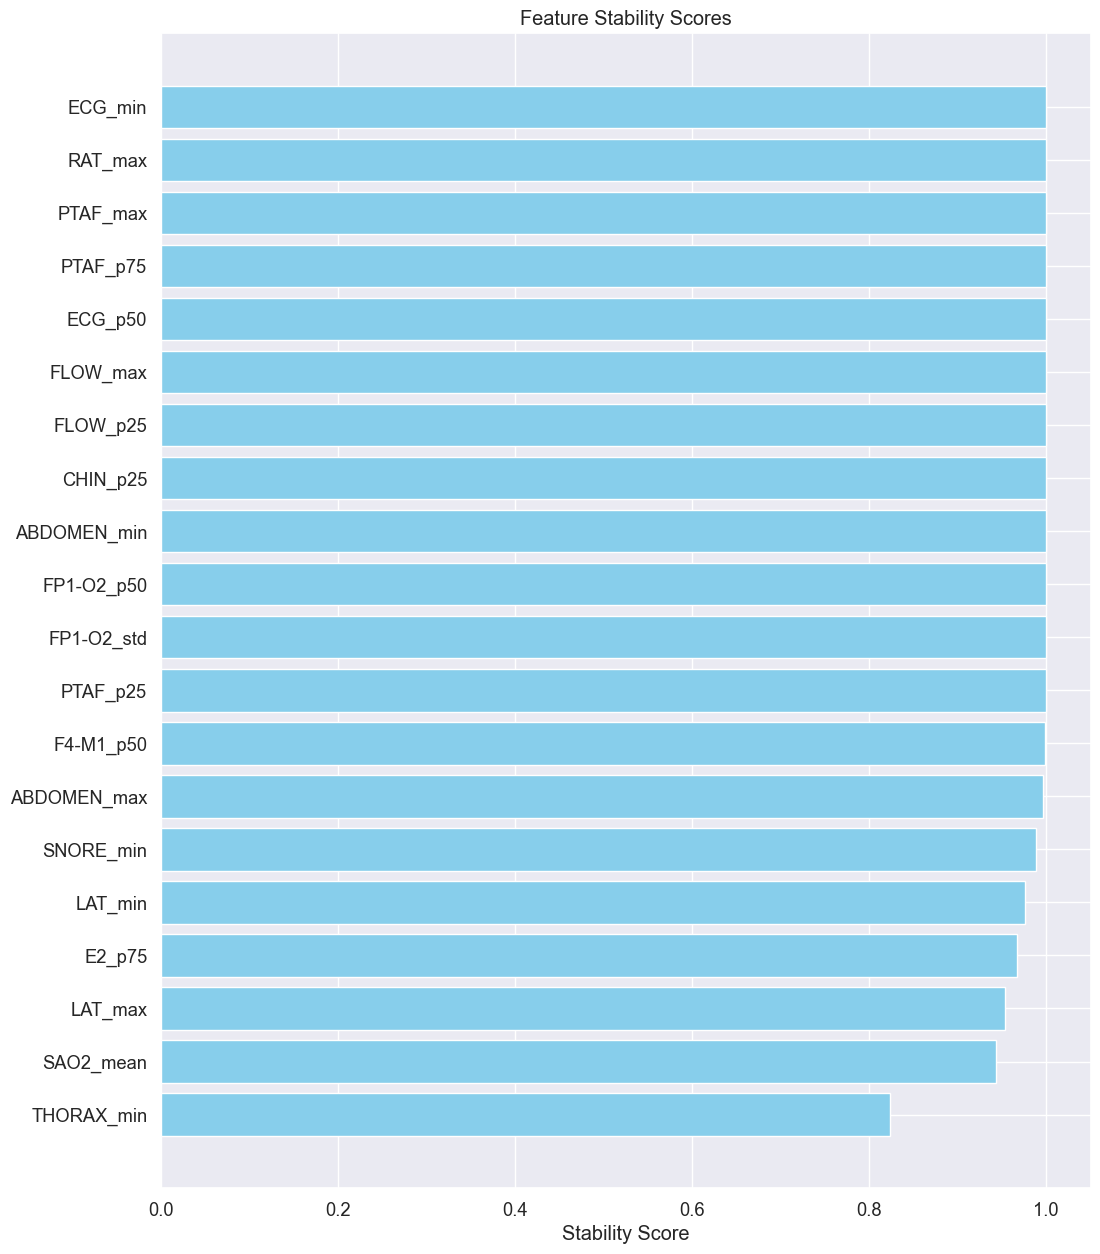

In [64]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.02;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

Number of Salient Features :25


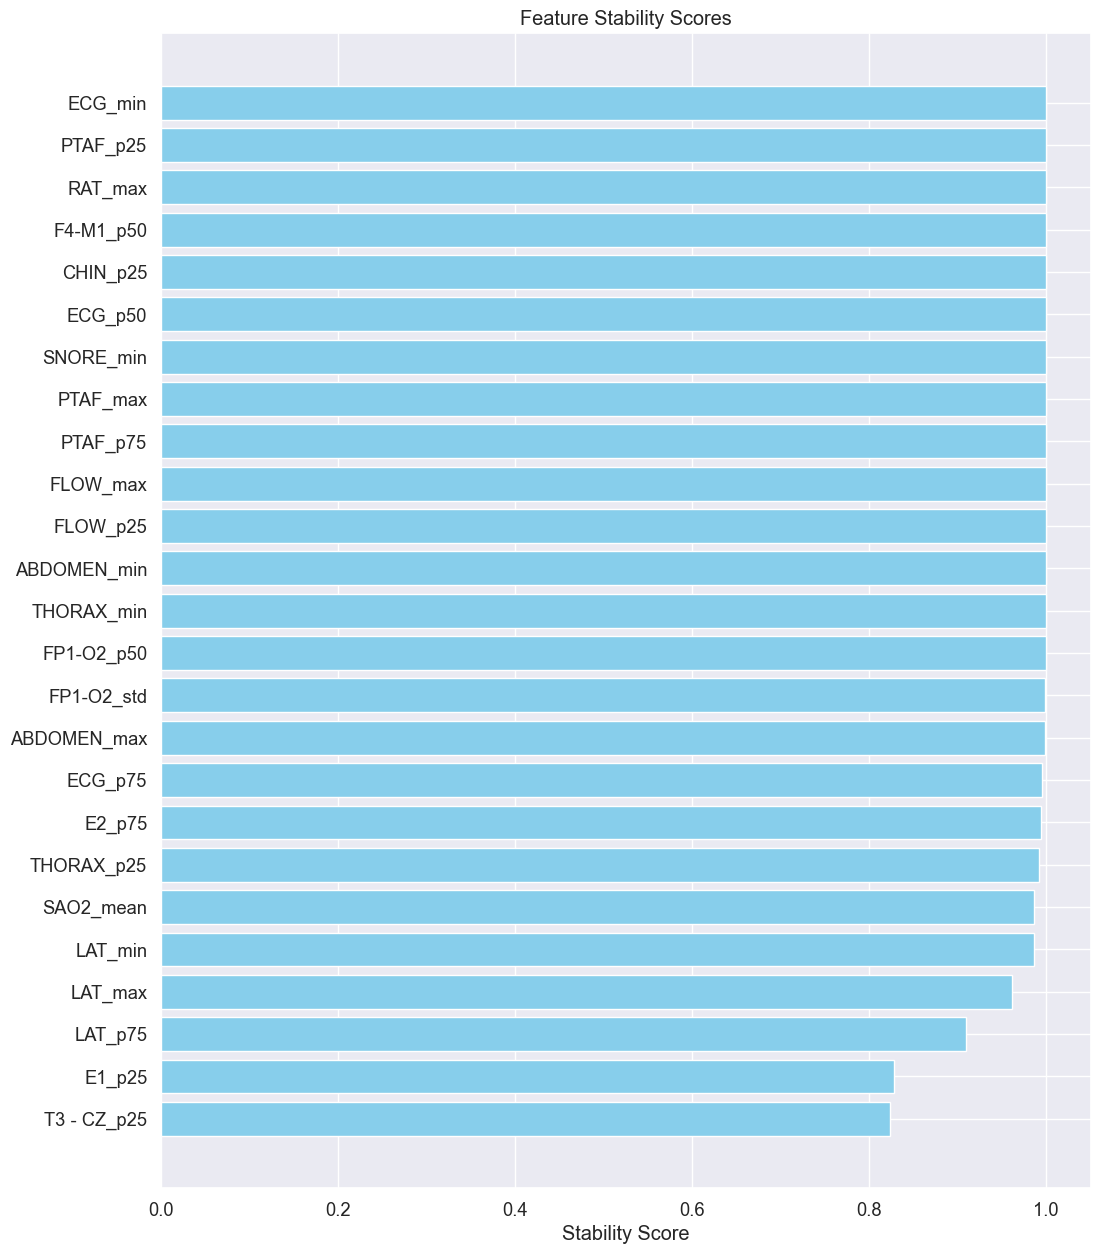

In [66]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.01;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [67]:
# feature_importance_df[feature_importance_df.Stability_Score>0.6]
# results[0.01]
feature_importance_df.shape

(25, 2)

In [68]:
alpha=0.02;
sc=0.5;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
feature_importance_df.shape

(22, 2)